In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("Wholesale customers data.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [7]:
df.shape

(440, 8)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
#df = df.drop_duplicates()

In [10]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [11]:
import matplotlib.pyplot as plt

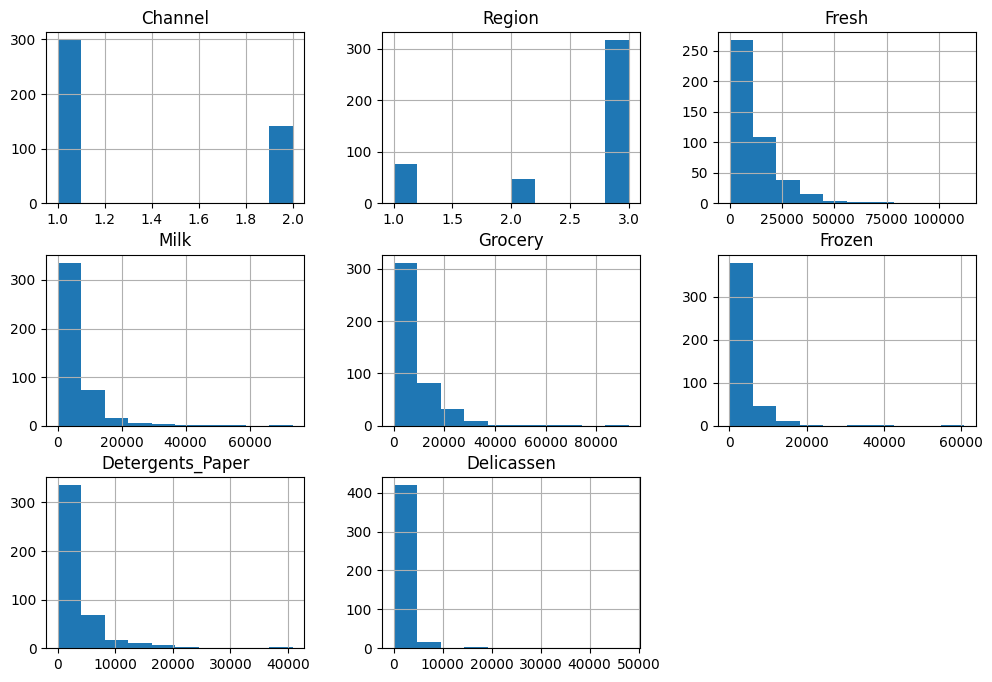

In [13]:
df.hist(figsize=(12,8))
plt.show()

In [14]:
import seaborn as sns

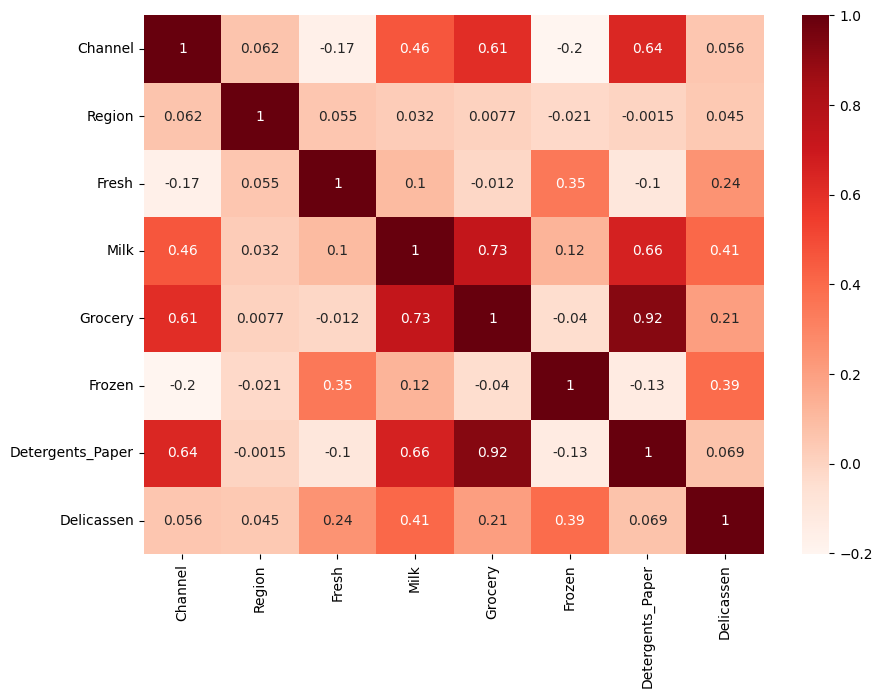

In [20]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),
           annot=True,
           cmap = "Reds"
           )
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

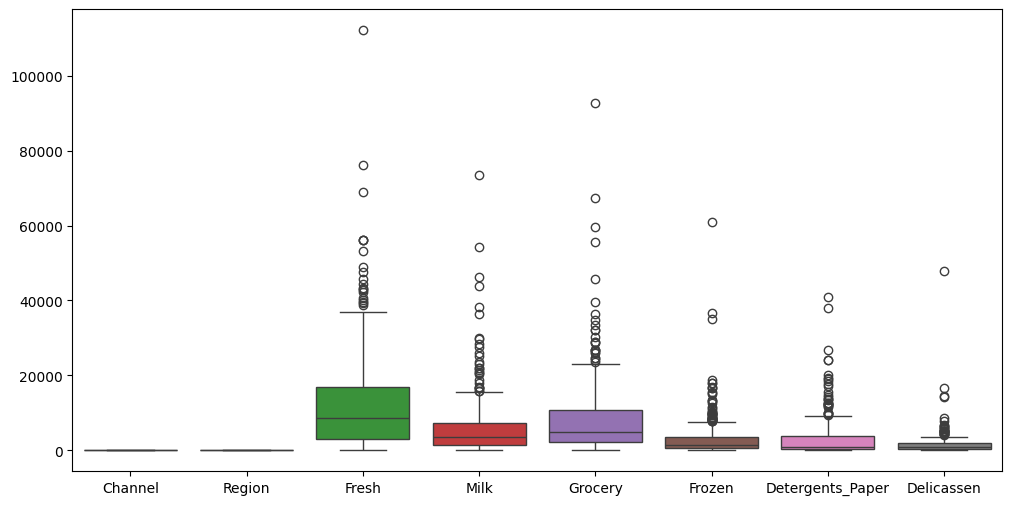

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

In [24]:
scaled_data = scaler.fit_transform(df)
scaled_data

array([[ 1.44865163,  0.59066829,  0.05293319, ..., -0.58936716,
        -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197, ..., -0.27013618,
         0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926, ..., -0.13753572,
         0.13323164,  2.24329255],
       ...,
       [ 1.44865163,  0.59066829,  0.20032554, ..., -0.54337975,
         2.51121768,  0.12145607],
       [-0.69029709,  0.59066829, -0.13538389, ..., -0.41944059,
        -0.56977032,  0.21304614],
       [-0.69029709,  0.59066829, -0.72930698, ..., -0.62009417,
        -0.50488752, -0.52286938]], shape=(440, 8))

In [25]:
from scipy.cluster.hierarchy import dendrogram , linkage

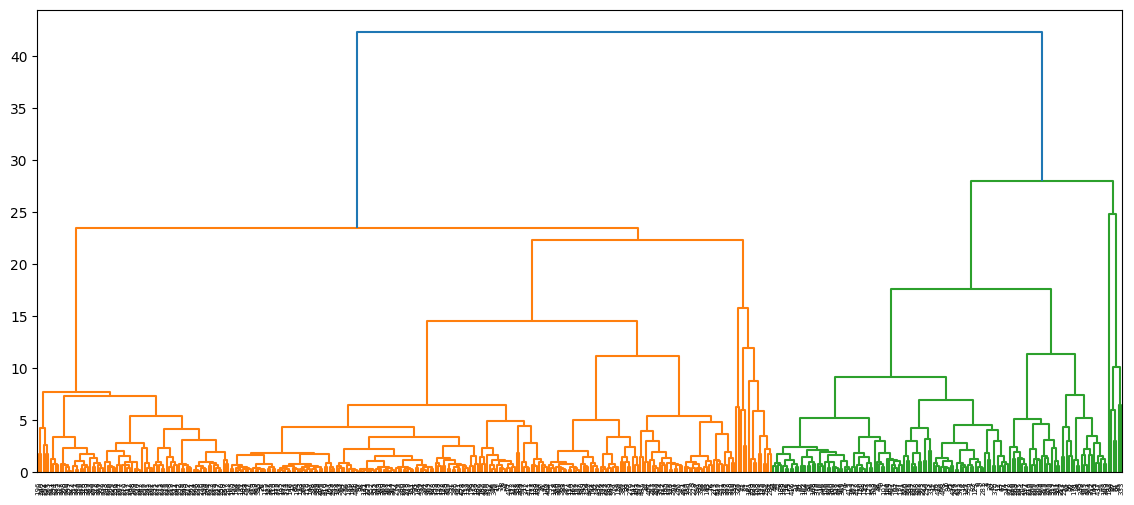

In [27]:
linkage_matrix = linkage(scaled_data, method="ward")
plt.figure(figsize=(14,6))
dendrogram(linkage_matrix)
plt.show()

In [29]:
from sklearn.cluster import AgglomerativeClustering

In [30]:
model = AgglomerativeClustering(
       n_clusters=5,
       linkage="ward"
)


In [44]:
clusters = model.fit_predict(scaled_data)
df["clusters"] = clusters
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,clusters
0,2,3,12669,9656,7561,214,2674,1338,2
1,2,3,7057,9810,9568,1762,3293,1776,2
2,2,3,6353,8808,7684,2405,3516,7844,2
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,2


In [45]:
df["clusters"].value_counts()

clusters
0    220
2    136
4     78
1      5
3      1
Name: count, dtype: int64

In [46]:
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [51]:
from sklearn.decomposition import PCA

In [53]:
pca = PCA(n_components=2)
data_2d = pca.fit_transform(scaled_data)
type(clusters)

numpy.ndarray

<function matplotlib.pyplot.show(close=None, block=None)>

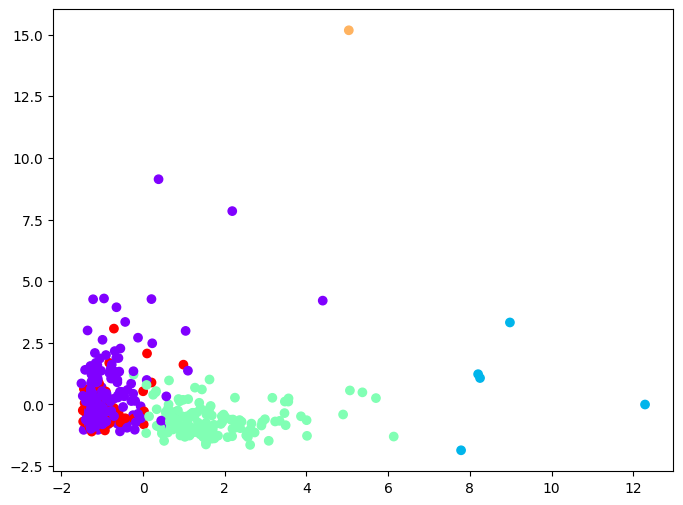

In [56]:
plt.figure(figsize=(8,6))
plt.scatter(
    data_2d[:,0],
    data_2d[:,1],
    c = clusters,
    cmap="rainbow"
)
plt.show

In [57]:
score = silhouette_score(scaled_data, clusters)
print("score :", score)

score : 0.3178066486005939


In [ ]:
#hier 

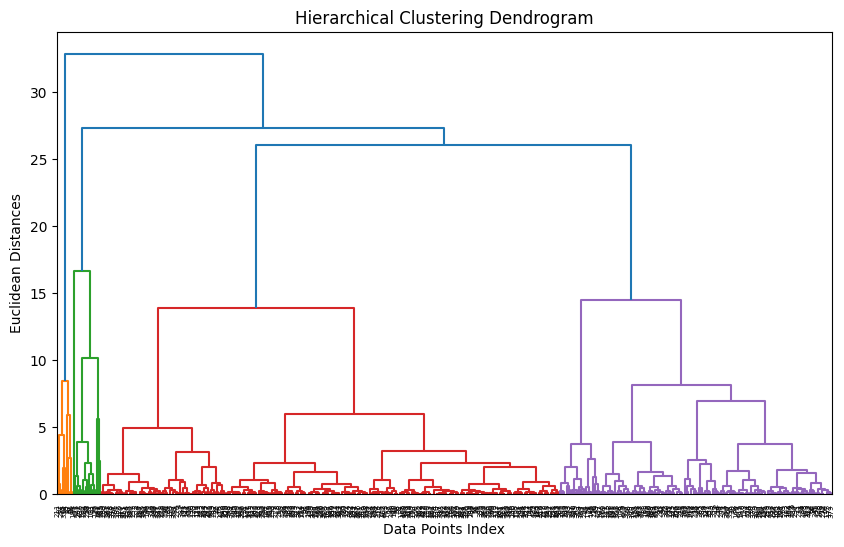

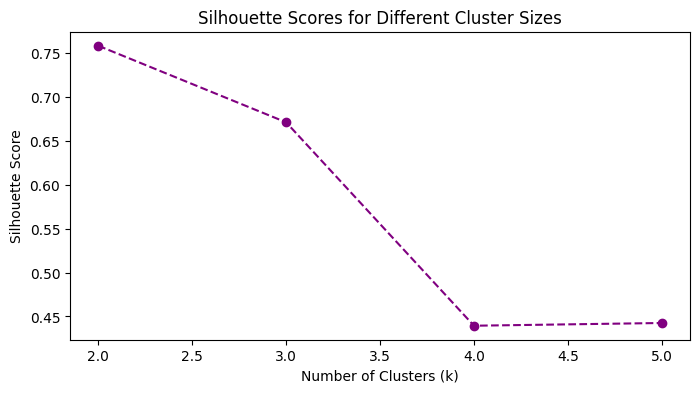

--> Mathematically Optimal Number of Clusters Detected: 2 (Score: 0.7583)

=== CLUSTER BUSINESS PROFILES (AVERAGE SPENDING PER GROUP) ===
                Fresh          Milk       Grocery       Frozen  \
Cluster                                                          
0        11889.976798   5181.354988   7053.501160  3071.276102   
1        17283.444444  35243.666667  50944.777778  3103.333333   

         Detergents_Paper   Delicassen  
Cluster                                 
0             2405.672854  1491.542923  
1            25668.000000  3120.888889  


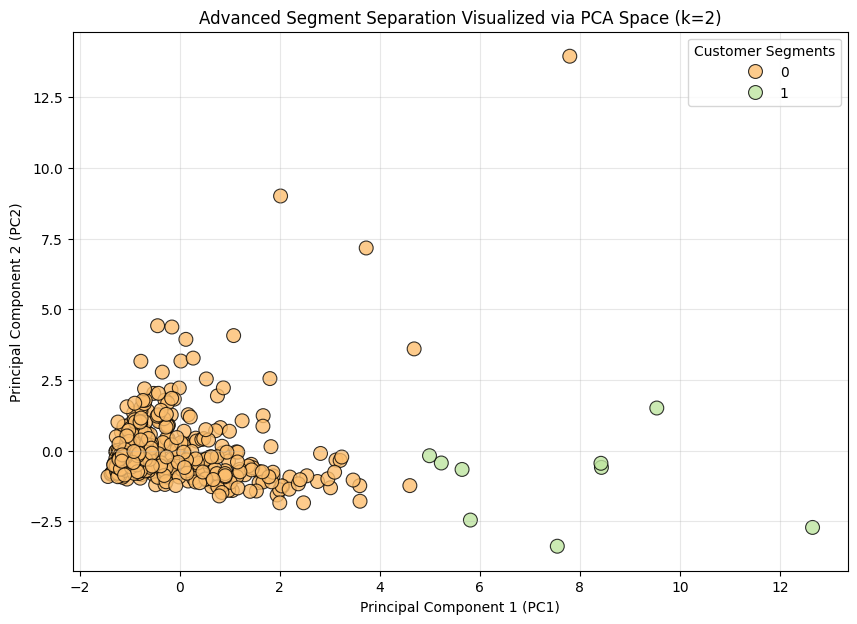

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

## STEP 1: LOADING AND CLEANING DATA
df = pd.read_csv("Wholesale customers data.csv")
X_raw = df.drop(columns=['Channel', 'Region'], errors='ignore')

## STEP 2: ADVANCED FEATURE SCALING & PCA DIMENSIONALITY REDUCTION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

## STEP 3: DENDROGRAM VISUALIZATION
plt.figure(figsize=(10, 6))
plt.title("Hierarchical Clustering Dendrogram")
dend = shc.dendrogram(shc.linkage(df_pca, method='ward'))
plt.xlabel("Data Points Index")
plt.ylabel("Euclidean Distances")
plt.show()

## STEP 4: AUTOMATED OPTIMAL CLUSTER SELECTION (SILHOUETTE ANALYSIS)
best_k = 2
best_score = -1
silhouette_scores = []
k_range = range(2, 6)

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = model.fit_predict(df_pca)
    score = silhouette_score(df_pca, labels)
    silhouette_scores.append(score)
    if score > best_score:
        best_score = score
        best_k = k

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='purple', linestyle='--')
plt.title("Silhouette Scores for Different Cluster Sizes")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

print(f"--> Mathematically Optimal Number of Clusters Detected: {best_k} (Score: {best_score:.4f})")

## STEP 5: FINAL MODEL TRAINING
final_model = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
df['Cluster'] = final_model.fit_predict(df_pca)
df_pca['Cluster'] = df['Cluster']

## STEP 6: BUSINESS PROFILING (UNDERSTANDING THE SEGMENTS)
print("\n=== CLUSTER BUSINESS PROFILES (AVERAGE SPENDING PER GROUP) ===")
profile = df.groupby('Cluster')[X_raw.columns].mean()
print(profile)

## STEP 7: ADVANCED CLUSTER SCATTER PLOT
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='Spectral', s=100, alpha=0.8, edgecolor='black')
plt.title(f'Advanced Segment Separation Visualized via PCA Space (k={best_k})')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Customer Segments')
plt.grid(True, alpha=0.3)
plt.show()